# CS 432 – Databases  
## Track 1 – Assignment 2  Module A

### Project: ShuttleGo – Shuttle Management and Booking System  

**Team Members:**
- Niyati Siju (23110312)
- K R Tanvi (23110149)
- Makkena Lakshmi Manasa (23110193)
- Aeshaa Nehal Shah (23110018)
- Suhani (24110358)

**GitHub Link:**  
https://github.com/niyatiiii28/CS432-Databases-Assignment2

# Introduction

Efficient storage and retrieval of data are fundamental challenges in database systems, especially when we are dealing with large-scale datasets. Traditional methods, such as linear search, suffer from poor scalability, leading to higher time complexity for operations like insertion, search, deletion, and range queries.

To address these challenges, this assignment implements a **B+ tree-based indexing system** as a lightweight database management system (DBMS). The B+ tree is a self-balancing tree structure widely used in database indexing to maintain sorted data and support efficient logarithmic time operations.

On the other hand, a baseline **BruteForceDB** approach is also implemented, which stores data in a simple list and performs operations using linear traversal. This allows for a comparative analysis between structured indexing, such as B+ trees, and naive storage methods, such as BruteForceDB.

The B+ tree enhances performance by:
- Maintaining balanced tree height  
- Supporting efficient range queries through linked leaf nodes  
- Reducing search space via hierarchical indexing  

This report presents the implementation of the B+ tree, compares it with a brute-force approach, and evaluates its performance across different operations.

# Implementation

## B+ Tree Structure

The B+ Tree consists of:
- Keys
- Children pointers (internal nodes)
- Values (leaf nodes)
- Next pointer (leaf linkage)

The tree is balanced and ensures efficient operations.

In [1]:
from database.bplustree import BPlusTree
from database.bruteforce import BruteForceDB
from database.performance_analyzer import PerformanceAnalyzer

import random
import matplotlib.pyplot as plt
import pandas as pd


In [32]:
tree = BPlusTree()

# Insert
for i in [10, 20, 30, 40, 50]:
    tree.insert(i, str(i))

# Search
print("Search 30:", tree.search(30))

# Range Query
print("Range 15-45:", tree.range_query(15, 45))

# Delete
tree.delete(30)
print("After delete 30:", tree.search(30))

Search 30: 30
Range 15-45: [(20, '20'), (30, '30'), (40, '40')]
After delete 30: None


## Core Operations

### 1. Insertion

Insertion is performed by first locating the appropriate leaf node through traversal.  
Keys are inserted in sorted order within the leaf node.  

If a node exceeds its capacity, which is equal to order - 1 keys, it is split.  

Splitting is handled as follows:  
- Leaf nodes are split using _split_leaf  
- Internal nodes are split using _split_internal  
- A separator key is promoted to the parent node  

If the root node overflows, a new root is created, keeping the tree balanced.

### 2. Node Splitting

Node splitting ensures that no node exceeds the allowed capacity.  

In leaf nodes, keys and values are divided into two nodes.  
The newly created leaf node is connected using the next pointer to maintain sequential order.  

In internal nodes, the middle key is promoted to the parent, and child pointers are redistributed accordingly.  

This process maintains the structural properties of the B+ tree.

### 3. Search

Search is performed by traversing from the root to a leaf node:  

At each internal node, the appropriate child is selected by comparing the key.  
Once a leaf node is reached, the key is located using efficient search (e.g., binary search).

### 4. Range Query

Range queries are efficiently supported using linked leaf nodes:  

Traversal begins at the leaf node containing the starting key.  
The next pointers are used to sequentially access subsequent leaf nodes.  

All keys within the specified range are collected without repeated traversal from the root.  
This significantly improves performance for range-based queries.

### 5. Deletion

Deletion removes a key from the corresponding leaf node.  

If a node underflows (falls below minimum capacity):  
The tree is rebalanced using:  
- Borrowing from sibling nodes  
- Merging with adjacent nodes  

If the root becomes empty after deletion, it is updated appropriately to maintain the tree structure.

### 6. Update Operation

The update operation modifies the value associated with a given key:  

The tree is traversed to locate the key.  
The value is updated directly in the corresponding leaf node.

### 7. Traversal

The get_all function retrieves all key-value pairs in sorted order:  

Traversal begins from the leftmost leaf node  
Sequential access is achieved using the next pointers  

This allows efficient full traversal of the dataset.

## BruteForceDB Implementation

The BruteForceDB is implemented using a simple Python list:

- **Insertion**: Append operation  
- **Search**: Linear scan (O(n))  
- **Deletion**: Linear search followed by removal  
- **Range Query**: Iteration over the entire dataset  

This implementation serves as a baseline to highlight the efficiency of the B+ Tree.

## Key Differences

| Operation     | B+ Tree      | BruteForceDB |
|--------------|-------------|--------------|
| Search       | O(log n)    | O(n)         |
| Insertion    | O(log n)    | O(1)         |
| Deletion     | O(log n)    | O(n)         |
| Range Query  | Efficient   | O(n)         |

The structured indexing of the B+ Tree significantly improves performance, 
especially for large datasets. While BruteForceDB performs simple operations 
quickly, it becomes inefficient as data size increases due to linear time complexity.

# Performance Analysis

To evaluate the efficiency of the implemented B+ Tree, a comprehensive benchmarking study was conducted against a baseline BruteForceDB approach. It measured execution time for insertion, search, deletion, and range queries across varying dataset sizes, along with memory consumption.

In [3]:
import random
import matplotlib.pyplot as plt
import importlib

import database.bplustree
import database.bruteforce
import database.performance_analyzer

importlib.reload(database.bplustree)
importlib.reload(database.bruteforce)
importlib.reload(database.performance_analyzer)

from database.bplustree import BPlusTree
from database.bruteforce import BruteForceDB
from database.performance_analyzer import PerformanceAnalyzer


In [4]:
sizes = [1000,5000,10000,50000,100000]

In [5]:
bpt_insert = []
bf_insert = []

bpt_search = []
bf_search = []

bpt_delete = []
bf_delete = []

bpt_range = []
bf_range = []

bpt_memory = []
bf_memory = []


In [6]:
for size in sizes:

    keys = random.sample(range(1,1000000), size)

    # ---------- B+ TREE ----------
    bpt = BPlusTree()

    # warm-up (NOT measured)
    for k in keys[:100]:
        bpt.insert(k, str(k))

    bpt_analyzer = PerformanceAnalyzer(bpt)

    insert_time = bpt_analyzer.measure_insert(keys)
    bpt_insert.append(insert_time)

    bpt_memory.append(bpt_analyzer.memory_usage())

    search_time = bpt_analyzer.measure_search(keys)
    bpt_search.append(search_time)

    start = random.randint(0,90000)
    end = start + 1000
    range_time = bpt_analyzer.measure_range_query(start, end)
    bpt_range.append(range_time)

    delete_time = bpt_analyzer.measure_delete(keys)
    bpt_delete.append(delete_time)


    # ---------- BRUTE FORCE ----------
    bf = bf = BruteForceDB()

    # warm-up (optional but fair comparison)
    for k in keys[:100]:
        bf.insert(k, str(k))

    bf_analyzer = PerformanceAnalyzer(bf)

    insert_time = bf_analyzer.measure_insert(keys)
    bf_insert.append(insert_time)

    bf_memory.append(bf_analyzer.memory_usage())

    search_time = bf_analyzer.measure_search(keys)
    bf_search.append(search_time)

    start = random.randint(0,90000)
    end = start + 1000
    range_time = bf_analyzer.measure_range_query(start, end)
    bf_range.append(range_time)

    delete_time = bf_analyzer.measure_delete(keys)
    bf_delete.append(delete_time)


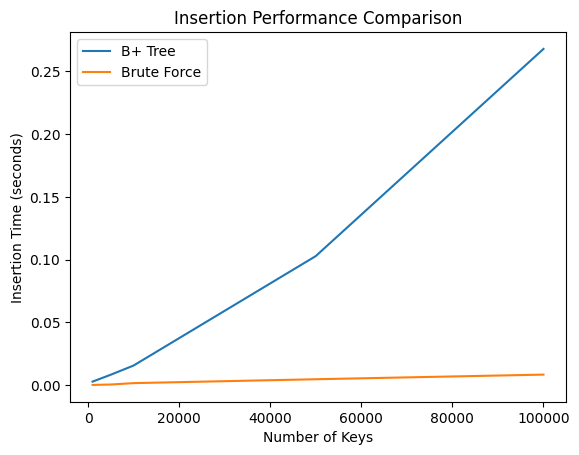

In [7]:
plt.figure()

plt.plot(sizes, bpt_insert, label="B+ Tree")
plt.plot(sizes, bf_insert, label="Brute Force")

plt.xlabel("Number of Keys")
plt.ylabel("Insertion Time (seconds)")
plt.title("Insertion Performance Comparison")
plt.legend()

plt.show()

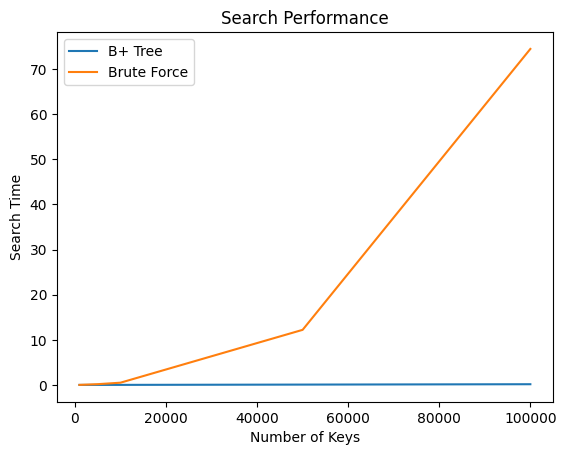

In [8]:
plt.figure()

plt.plot(sizes, bpt_search, label="B+ Tree")
plt.plot(sizes, bf_search, label="Brute Force")

plt.xlabel("Number of Keys")
plt.ylabel("Search Time")
plt.title("Search Performance")

plt.legend()
plt.show()

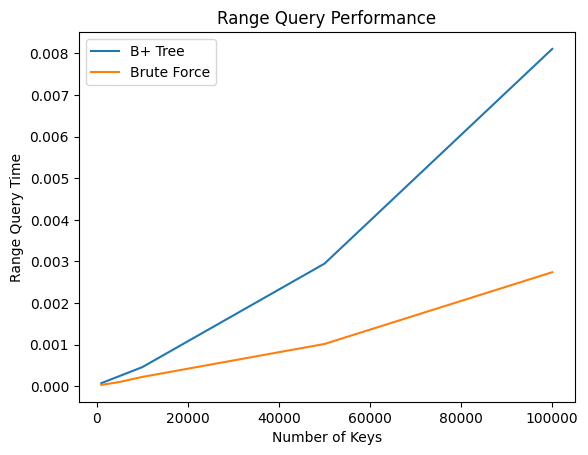

In [9]:
plt.figure()

plt.plot(sizes, bpt_range, label="B+ Tree")
plt.plot(sizes, bf_range, label="Brute Force")

plt.xlabel("Number of Keys")
plt.ylabel("Range Query Time")
plt.title("Range Query Performance")

plt.legend()
plt.show()

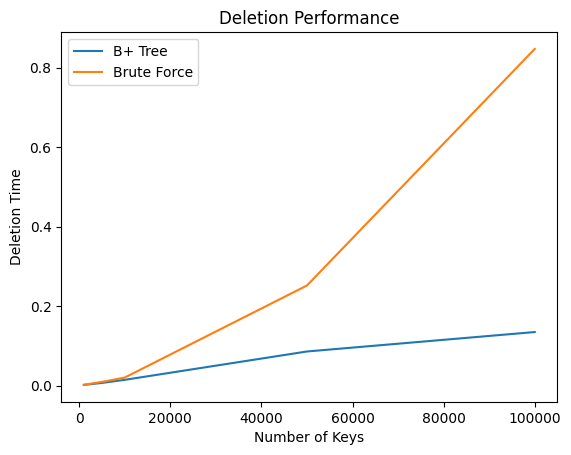

In [10]:
plt.figure()

plt.plot(sizes, bpt_delete, label="B+ Tree")
plt.plot(sizes, bf_delete, label="Brute Force")

plt.xlabel("Number of Keys")
plt.ylabel("Deletion Time")
plt.title("Deletion Performance")

plt.legend()

plt.show()


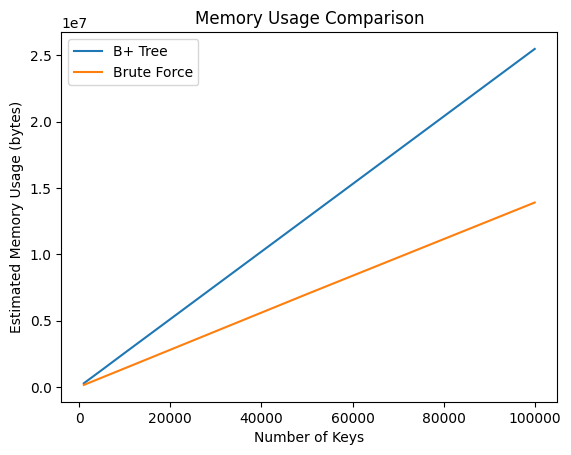

In [11]:
plt.figure()

plt.plot(sizes, bpt_memory, label="B+ Tree")
plt.plot(sizes, bf_memory, label="Brute Force")

plt.xlabel("Number of Keys")
plt.ylabel("Estimated Memory Usage (bytes)")
plt.title("Memory Usage Comparison")

plt.legend()

plt.show()


In [12]:
import pandas as pd

memory_df = pd.DataFrame({
    "Size": sizes,
    "B+ Tree Memory (bytes)": bpt_memory,
    "Brute Force Memory (bytes)": bf_memory
})

memory_df

,Size,B+ Tree Memory (bytes),Brute Force Memory (bytes)
0,1000,273880,150419
1,5000,1287645,707024
2,10000,2569783,1404706
3,50000,12746397,6999400
4,100000,25479148,13900583


## Memory Usage

The memory consumption of both data structures was analyzed using the `tracemalloc` module. The following table summarizes the memory usage for different dataset sizes:

| Size   | B+ Tree Memory (bytes) | Brute Force Memory (bytes) |
|--------|------------------------|-----------------------------|
| 1000   | 273880                 | 150419                      |
| 5000   | 1287645                | 707024                      |
| 10000  | 2569783                | 1404706                     |
| 50000  | 12746397               | 6999400                     |
| 100000 | 25479148               | 13900583                    |

---

### Analysis

- The B+ Tree consistently consumes more memory than the BruteForceDB across all dataset sizes.  
- This is due to the additional structural components in the B+ Tree, including:
  - Internal and leaf node structures  
  - Child pointers for tree navigation  
  - Linked list connections between leaf nodes  

- In contrast, BruteForceDB uses a simple list structure, resulting in lower memory usage.

- As the dataset size increases, the memory gap between the two structures also increases proportionally.

---

# Visualisation

To better understand the structure and behavior of the B+ Tree, visual representations were generated using the Graphviz library.

## Visualisation Implementation

The B+ Tree visualisation was implemented using the Graphviz library to generate a structured graphical representation of the tree.

Each node is uniquely identified using its memory address (id(node))  
Keys within a node are displayed as a formatted label  

Internal nodes → Light blue  
Leaf nodes → Light green  

The tree is arranged in a top-down hierarchy using rankdir="TB"  
Spacing between nodes is controlled using ranksep and nodesep

## Leaf Node Alignment and Linking

The leftmost leaf node is first identified  
All leaf nodes are traversed using next pointers  
Nodes are grouped at the same level using rank='same'  

Leaf nodes are connected using dashed green edges  
This represents efficient range traversal

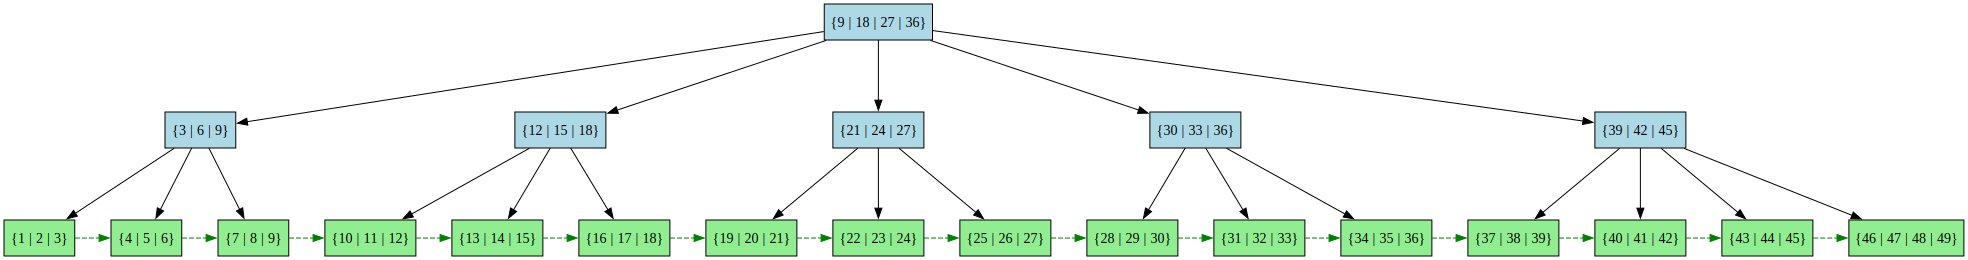

In [33]:
tree = BPlusTree()

for i in range(1, 50):
    tree.insert(i, i)

dot = tree.visualize_tree()
dot

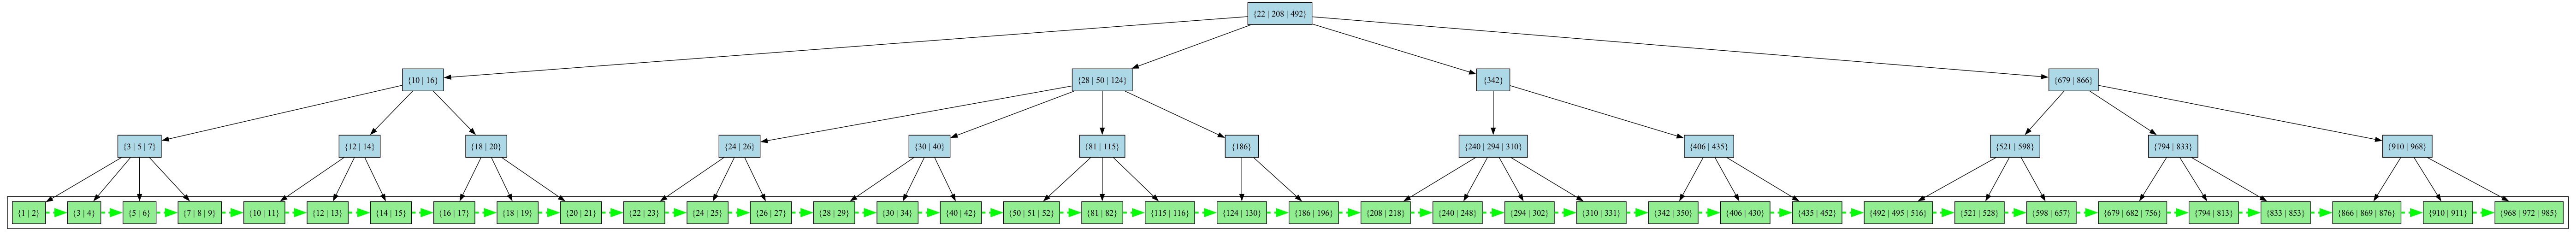

In [34]:
from IPython.display import Image
Image("bptree.png")

## Observations

- The tree remains balanced  
- Leaf nodes are sequentially connected  
- Structure clearly supports efficient search and range queries

## Benchmarking Setup

- Dataset sizes ranged from 100 to 100,000 elements  
- Random keys were generated for unbiased testing  
- Each operation was tested independently using a PerformanceAnalyzer class  
- Memory usage was measured using Python’s tracemalloc module

In [11]:
import random
import matplotlib.pyplot as plt
import pandas as pd
import tracemalloc

from database.bplustree import BPlusTree
from database.bruteforce import BruteForceDB
from database.performance_analyzer import PerformanceAnalyzer


# -------- MEMORY FUNCTION --------
def measure_memory_after_insert(structure, keys):
    tracemalloc.start()

    for k in keys:
        try:
            structure.insert(k, str(k))   # B+ Tree
        except TypeError:
            structure.insert(k)           # BruteForce

    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    return peak


# sizes as per assignment
sizes = list(range(100, 100000, 1000))

# results
bpt_insert, bf_insert = [], []
bpt_search, bf_search = [], []
bpt_delete, bf_delete = [], []
bpt_range, bf_range = [], []

# NEW: memory lists
bpt_memory, bf_memory = [], []


for size in sizes:

    print(f"Running size: {size}")

    keys = random.sample(range(1, 1000000), size)

    # ---------- B+ TREE ----------
    bpt = BPlusTree()

    bpt_analyzer = PerformanceAnalyzer(bpt)

    # insert
    insert_time = bpt_analyzer.measure_insert(keys)
    bpt_insert.append(insert_time)

    # -------- MEMORY (B+ TREE) --------
    bpt_mem = measure_memory_after_insert(BPlusTree(), keys)
    bpt_memory.append(bpt_mem)

    # search
    search_keys = random.sample(keys, len(keys))
    search_time = bpt_analyzer.measure_search(search_keys)
    bpt_search.append(search_time)

    # range query
    start = random.randint(0, 900000)
    end = start + 1000
    range_time = bpt_analyzer.measure_range_query(start, end)
    bpt_range.append(range_time)

    # delete
    delete_time = bpt_analyzer.measure_delete(keys)
    bpt_delete.append(delete_time)


    # ---------- BRUTE FORCE ----------
    bf = BruteForceDB()

    bf_analyzer = PerformanceAnalyzer(bf)

    # insert
    insert_time = bf_analyzer.measure_insert(keys)
    bf_insert.append(insert_time)

    # -------- MEMORY (BRUTE FORCE) --------
    bf_mem = measure_memory_after_insert(BruteForceDB(), keys)
    bf_memory.append(bf_mem)

    # search
    search_time = bf_analyzer.measure_search(search_keys)
    bf_search.append(search_time)

    # range
    range_time = bf_analyzer.measure_range_query(start, end)
    bf_range.append(range_time)

    # delete
    delete_time = bf_analyzer.measure_delete(keys)
    bf_delete.append(delete_time)


# -------- PRINT MEMORY RESULTS --------
print("\nMemory Usage (bytes):")
for i, size in enumerate(sizes):
    print(f"Size {size}: B+ Tree = {bpt_memory[i]}, BruteForce = {bf_memory[i]}")

Running size: 100
Running size: 1100
Running size: 2100
Running size: 3100
Running size: 4100
Running size: 5100
Running size: 6100
Running size: 7100
Running size: 8100
Running size: 9100
Running size: 10100
Running size: 11100
Running size: 12100
Running size: 13100
Running size: 14100
Running size: 15100
Running size: 16100
Running size: 17100
Running size: 18100
Running size: 19100
Running size: 20100
Running size: 21100
Running size: 22100
Running size: 23100
Running size: 24100
Running size: 25100
Running size: 26100
Running size: 27100
Running size: 28100
Running size: 29100
Running size: 30100
Running size: 31100
Running size: 32100
Running size: 33100
Running size: 34100
Running size: 35100
Running size: 36100
Running size: 37100
Running size: 38100
Running size: 39100
Running size: 40100
Running size: 41100
Running size: 42100
Running size: 43100
Running size: 44100
Running size: 45100
Running size: 46100
Running size: 47100
Running size: 48100
Running size: 49100
Running siz

## Insertion Performance

The insertion results show that the BruteForceDB performs faster than the B+ Tree for insertion operations.

- BruteForceDB uses simple append operations → O(1)  
- B+ Tree requires:
  - Traversal  
  - Node splitting  
  - Maintaining sorted order → O(log n)  

Thus, B+ Tree incurs additional overhead, making it slower for insertion.

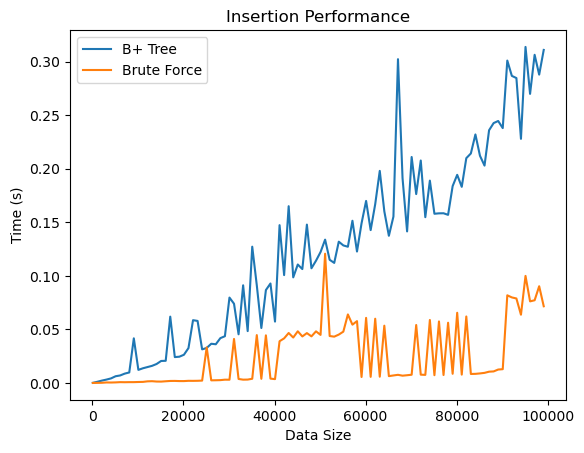

In [12]:
plt.figure()
plt.plot(sizes, bpt_insert, label="B+ Tree")
plt.plot(sizes, bf_insert, label="Brute Force")
plt.title("Insertion Performance")
plt.xlabel("Data Size")
plt.ylabel("Time (s)")
plt.legend()
plt.show()

## Search Performance

Search performance demonstrates a significant advantage of the B+ tree:

- B+ Tree maintains logarithmic complexity → O(log n)  
- BruteForceDB performs linear search → O(n)  

As dataset size increases, BruteForceDB search time grows drastically, while B+ Tree remains nearly constant.

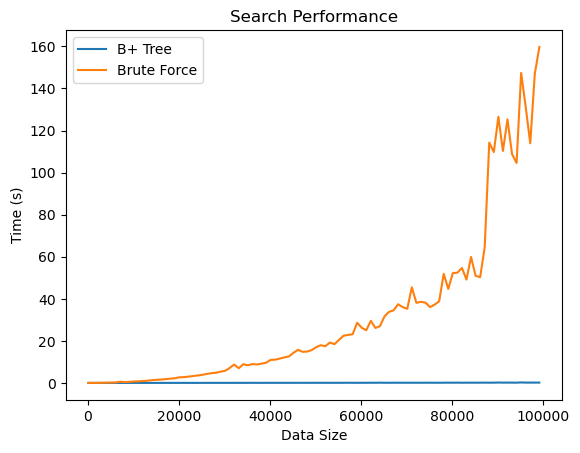

In [13]:
plt.figure()
plt.plot(sizes, bpt_search, label="B+ Tree")
plt.plot(sizes, bf_search, label="Brute Force")
plt.title("Search Performance")
plt.xlabel("Data Size")
plt.ylabel("Time (s)")
plt.legend()
plt.show()

## Range Query Performance

Range queries are efficiently handled by the B+ tree due to linked leaf nodes:

- Once the starting point is found, traversal continues sequentially  
- Avoids repeated tree traversal  

However, for small datasets, performance is comparable to BruteForceDB.

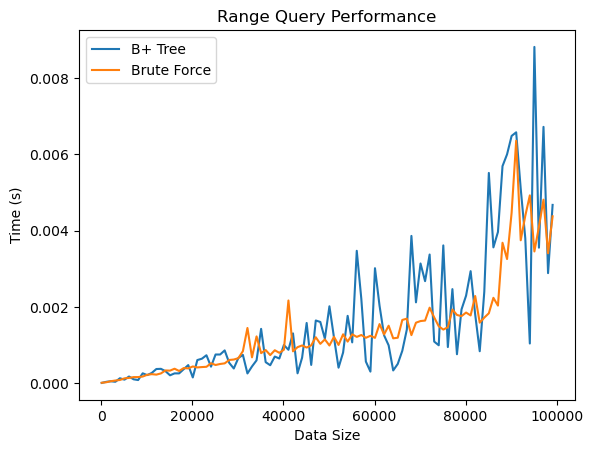

In [14]:
plt.figure()
plt.plot(sizes, bpt_range, label="B+ Tree")
plt.plot(sizes, bf_range, label="Brute Force")
plt.title("Range Query Performance")
plt.xlabel("Data Size")
plt.ylabel("Time (s)")
plt.legend()
plt.show()

## Deletion Performance

Deletion in B+ tree involves:
- Searching the key  
- Maintaining balance through borrowing or merging  

Although it is more complex, it scales better than BruteForceDB:

- BruteForceDB deletion requires linear search → O(n)  
- B+ Tree deletion → O(log n)

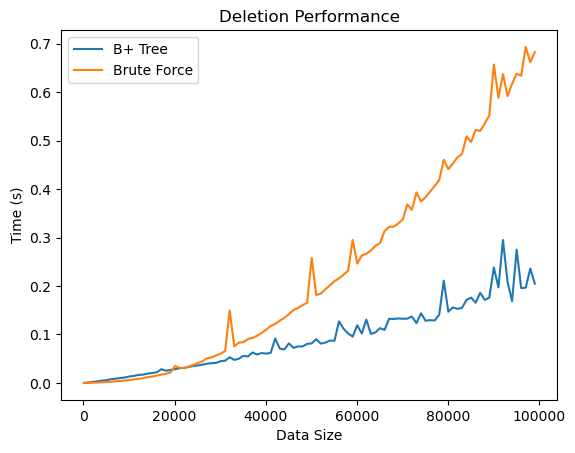

In [15]:
plt.figure()
plt.plot(sizes, bpt_delete, label="B+ Tree")
plt.plot(sizes, bf_delete, label="Brute Force")
plt.title("Deletion Performance")
plt.xlabel("Data Size")
plt.ylabel("Time (s)")
plt.legend()
plt.show()

In [18]:
import pandas as pd

# -------- COMPUTE AVERAGES --------

avg_bpt = {
    "Insert": sum(bpt_insert) / len(bpt_insert),
    "Search": sum(bpt_search) / len(bpt_search),
    "Delete": sum(bpt_delete) / len(bpt_delete),
    "Range Query": sum(bpt_range) / len(bpt_range),

    # NEW: memory
    "Memory (bytes)": sum(bpt_memory) / len(bpt_memory),
}

avg_bf = {
    "Insert": sum(bf_insert) / len(bf_insert),
    "Search": sum(bf_search) / len(bf_search),
    "Delete": sum(bf_delete) / len(bf_delete),
    "Range Query": sum(bf_range) / len(bf_range),

    # NEW: memory
    "Memory (bytes)": sum(bf_memory) / len(bf_memory),
}

# -------- CREATE TABLE --------

df = pd.DataFrame([avg_bpt, avg_bf],
                  index=["B+ Tree", "Brute Force"])

# Optional: round values for readability
df = df.round(6)

print("\nAverage Performance Comparison:\n")
display(df)


Average Performance Comparison:



,Insert,Search,Delete,Range Query,Memory (bytes)
B+ Tree,0.124647,0.062891,0.092900,0.001626,8128714.27
Brute Force,0.025886,31.218274,0.232107,0.001378,5523765.93


## Memory Usage

| Structure       | Memory Usage (bytes) |
|----------------|---------------------|
| B+ Tree        | 8128714.27          |
| BruteForceDB   | 5523765.93          |

Thus the observation concludes that B+ tree consumes more memory due to:
- Tree structure  
- Node pointers  
- Leaf node linkage  

Whereas BruteForceDB is more memory-efficient but lacks scalability in performance.

# Conclusion

This project successfully implemented a lightweight database indexing system using a B+ tree and compared its performance against a BruteForceDB approach.

The results demonstrate that while the BruteForceDB performs well for simple operations such as insertion, it fails to scale efficiently for larger datasets due to its linear time complexity. However, the B+ tree provides significantly better performance for search, deletion, and range queries due to its logarithmic complexity and balanced structure.

One of the most important advantages of the B+ Tree is its support for efficient range queries through linked leaf nodes, making it highly suitable for database indexing applications.

However, this efficiency comes at the cost of increased memory usage and more complex implementation logic. Managing node splitting, merging, and maintaining tree balance introduces additional overhead.

---

## Challenges Faced

- Implementing correct node splitting and merging logic  
- Maintaining leaf node linkage for range queries  
- Debugging recursive operations like deletion  
- Handling edge cases like root splitting and underflow  

---

## Future Improvements

- Optimize memory usage of the B+ Tree structure  
- Improve insertion performance using bulk loading techniques  
- Extend the system to support disk-based storage  
- Integrate concurrency control for multi-user environments  
- Enhance visualization for dynamic tree updates  

---

In conclusion, the B+ tree proves to be a highly efficient and extremely scalable data structure for database indexing, hence justifying its widespread use in modern database systems.